In [1]:
import numpy as np, matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib
import corner
import re
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import BaryonForge as bfg
import pyccl as ccl
from scipy.integrate import cumulative_trapezoid, simpson
from astropy import constants as con
import os
import emcee

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
sns.set(font_scale=2)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Times New Roman'

cmap = plt.get_cmap("rainbow")
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

from astropy.cosmology import Planck18 as cosmo
cosmo_ccl = ccl.Cosmology(Omega_c = cosmo.Om0-cosmo.Ob0, 
                          Omega_b = cosmo.Ob0, 
                          h = cosmo.H0.value/100, 
                          sigma8 = 0.8111, 
                          n_s = 0.9665, 
                          matter_power_spectrum='linear'
                         )

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 2   # thickness of the plot box
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1

mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5


## DES + WISE/Spitzer + SPT Clusters data

In [2]:
spt_cluster_redshifts = pd.read_csv("data/shm_relation/spt_cluster_redshifts.dat", sep="\t", comment="(", skiprows=[1])
spt_clusters = pd.read_csv("data/shm_relation/spt_clusters.dat", sep="\t", comment="(", skiprows=[1])

def split_pm(value):
    """Split a string like '4.13 ± 0.59' into (4.13, 0.59)."""
    if isinstance(value, str):
        value = value.strip()
        if value in ["–", "-", "", "nan"]:
            return np.nan, np.nan
        match = re.match(r"([+-]?\d*\.?\d+)\s*[±]\s*([+-]?\d*\.?\d+)", value)
        if match:
            return float(match.group(1)), float(match.group(2))
        try:
            return float(value), np.nan
        except ValueError:
            return np.nan, np.nan
    return value, np.nan

cols_to_split = [c for c in spt_clusters.columns if c not in ["Name"]]

for col in cols_to_split:
    vals, errs = zip(*spt_clusters[col].map(split_pm))
    spt_clusters[col] = vals
    spt_clusters[col + "_err"] = errs

spt_clusters = spt_clusters.merge(spt_cluster_redshifts, on='Name', how='inner')

from colossus.halo import mass_defs
from colossus.cosmology import cosmology
cosmology.setCosmology('planck18')

spt_clusters['M200'] = np.array([mass_defs.changeMassDefinition((10**14)*spt_clusters['M500'][i], 1, spt_clusters['z'][i], '500c', '200c')[0] for i in range(len(spt_clusters))])
spt_clusters['M200_err'] = np.array([mass_defs.changeMassDefinition((10**14)*(spt_clusters['M500'][i]+spt_clusters['M500_err'][i]), 1, spt_clusters['z'][i], '500c', '200c')[0] for i in range(len(spt_clusters))])-spt_clusters['M200']
spt_clusters['M⋆'] = spt_clusters['M⋆']*1e12; spt_clusters['M⋆_err'] = spt_clusters['M⋆_err']*1e12
spt_clusters['M500'] = spt_clusters['M500']*1e14; spt_clusters['M500_err'] = spt_clusters['M500_err']*1e14

spt_clusters['Mstar_M500'] = spt_clusters['M⋆'] / spt_clusters['M500']
spt_clusters['Mstar_M500_err'] = spt_clusters['Mstar_M500'] * np.sqrt(
    (spt_clusters['M⋆_err'] / spt_clusters['M⋆'])**2 + (spt_clusters['Mstar_M500'] / spt_clusters['M500'])**2
)



In [3]:
bins = np.linspace(spt_clusters['M500'].min(), spt_clusters['M500'].max(), 4)
spt_clusters['bin'] = pd.cut(spt_clusters['M500'], bins=bins, labels=False, include_lowest=True)

binned_spt_clusters = (
    spt_clusters.groupby('bin')
      .apply(lambda g: pd.Series({
          'M500_min': g['M500'].min(),
          'M500_max': g['M500'].max(),

          # M*/M500 weighted stats
          'mean_Mstar_M500': np.mean(np.array([np.random.normal(g['Mstar_M500'], g['Mstar_M500_err']) for i in range(1000)]).flatten()),
          'err_Mstar_M500': np.std(np.array([np.random.normal(g['Mstar_M500'], g['Mstar_M500_err']) for i in range(1000)]).flatten()),

          # M500 weighted stats
          'mean_M500': np.mean(np.array([np.random.normal(g['M500'], g['M500_err']) for i in range(1000)]).flatten()),
          'err_M500': np.std(np.array([np.random.normal(g['M500'], g['M500_err']) for i in range(1000)]).flatten()),

          'N': len(g)
      }))
)

binned_spt_clusters.reset_index(drop=True, inplace=True)
binned_spt_clusters



,M500_min,M500_max,mean_Mstar_M500,err_Mstar_M500,mean_M500,err_M500,N
0,2.630000e+14,5.970000e+14,0.009601,0.003233,4.489351e+14,9.185174e+13,69.0
1,6.230000e+14,9.460000e+14,0.008095,0.002746,7.253405e+14,1.360024e+14,11.0
2,9.600000e+14,1.305000e+15,0.007716,0.001252,1.129852e+15,1.929266e+14,3.0


## SDSS + Chandra Clusters data

In [4]:
# Mass in units of Msun; digitized numbers from figure 6 in Giri & Schneider

chandra_mass_med = np.array([10**13.695192229719042, 10**14.55322432872962])/cosmo_ccl.cosmo.params.h
chandra_mass_err_l = np.array([10**13.695192229719042-10**13.279761072224485, 10**14.55322432872962-10**14.11571214936257])/cosmo_ccl.cosmo.params.h
chandra_mass_err_h = np.array([10**14.108598403445344-10**13.695192229719042, 10**14.999931982494084-10**14.55322432872962])/cosmo_ccl.cosmo.params.h

chandra_mfrac_med = np.array([0.025479412434924364, 0.015226384336272327])
chandra_mfrac_err_l = np.array([0.025479412434924364-0.018276393977107397, 0.015226384336272327-0.00990990201405809])
chandra_mfrac_err_h = np.array([0.033536959455906325-0.025479412434924364, 0.02236104050903609-0.015226384336272327])


# f_star(M500) computed by integrating Baryonforge Profiles

In [5]:
def f_star_eta(Mass, eta):
    par = dict(theta_ej = 3.5, theta_co = 0.1, M_c = (10**14)/cosmo_ccl.cosmo.params.h, 
               mu_beta = 1, eta = eta, eta_delta = 0.2, tau = -1.5, tau_delta = 0, A = 0.055/2, 
               M1 = 2.5e11/cosmo_ccl.cosmo.params.h, epsilon_h = 0.015, a = 0.3, n = 2, 
               epsilon = 4, p = 0.3, q = 0.707, gamma = 2.5, delta = 9)
    mdef  = ccl.halos.massdef.MassDef500c
    CGA = bfg.Profiles.Schneider19.Stars(**par, mass_def = mdef, c_M_relation=ccl.halos.concentration.ConcentrationIshiyama21)
    SGA = bfg.Profiles.Schneider19.SatelliteStars(**par, mass_def = mdef, c_M_relation=ccl.halos.concentration.ConcentrationIshiyama21)
    R500c = mdef.get_radius(cosmo_ccl, Mass, 1) / 1
    out   = np.zeros_like(Mass) + -99
    for i in range(Mass.size):
        r = np.geomspace(R500c[i] * 1e-3, R500c[i] * 1, 1000)
        m_cga = np.trapz(4 * np.pi * r**2 * CGA.real(cosmo_ccl, r, Mass[i], 1), x = r)
        m_sga = np.trapz(4 * np.pi * r**2 * SGA.real(cosmo_ccl, r, Mass[i], 1), x = r)
        out[i] = (m_cga+m_sga)/Mass[i] 
    return out

def get_samples(mcmc_file):
    class RenameUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module.startswith("numpy._core"):
                module = module.replace("numpy._core", "numpy.core")
            return super().find_class(module, name)
    with open(mcmc_file, "rb") as f:
        results = RenameUnpickler(f).load()
    chain = results["chain"]
    samples = chain.reshape(-1, chain.shape[-1])
    # DMhost transformations
    DMhost_mean = np.exp(samples[:, -2] + ((samples[:, -1]**2)/2))
    DMhost_var = np.sqrt((np.exp(samples[:, -1]**2) - 1) * np.exp((2*samples[:, -2]) + (samples[:, -1]**2)))
    samples[:, -2] = DMhost_mean; samples[:, -1] = DMhost_var
    return samples


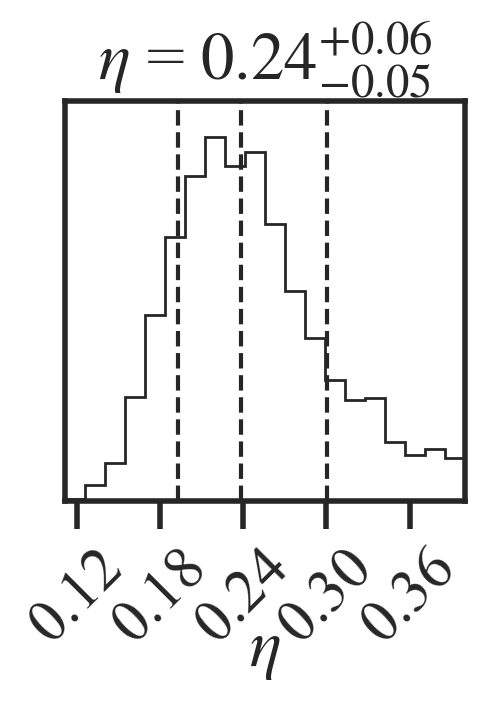

In [6]:
BCEmu5_samples = get_samples("data/frb_results/emcee_BCEmu5_extended_Chandraprior.pkl")
samples_chandra = BCEmu5_samples[:, 4]

fig = corner.corner(samples_chandra, labels=[r"$\eta$"], quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()


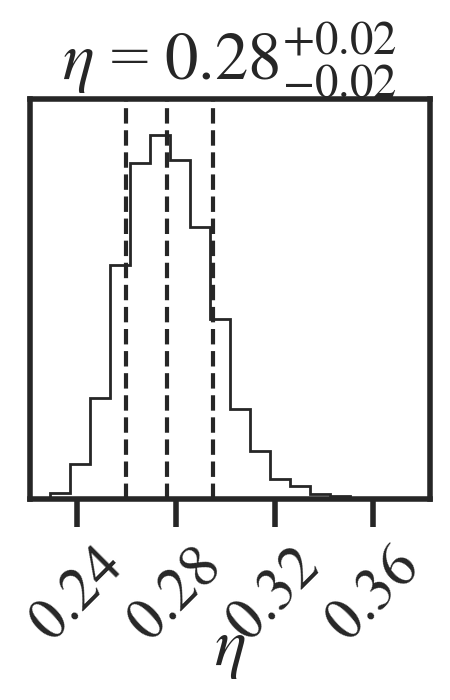

In [7]:
BCEmu5_samples = get_samples("data/frb_results/emcee_BCEmu5_extended_SPTprior.pkl")
samples_spt = BCEmu5_samples[:, 4]

fig = corner.corner(samples_spt, labels=[r"$\eta$"], quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.45it/s]


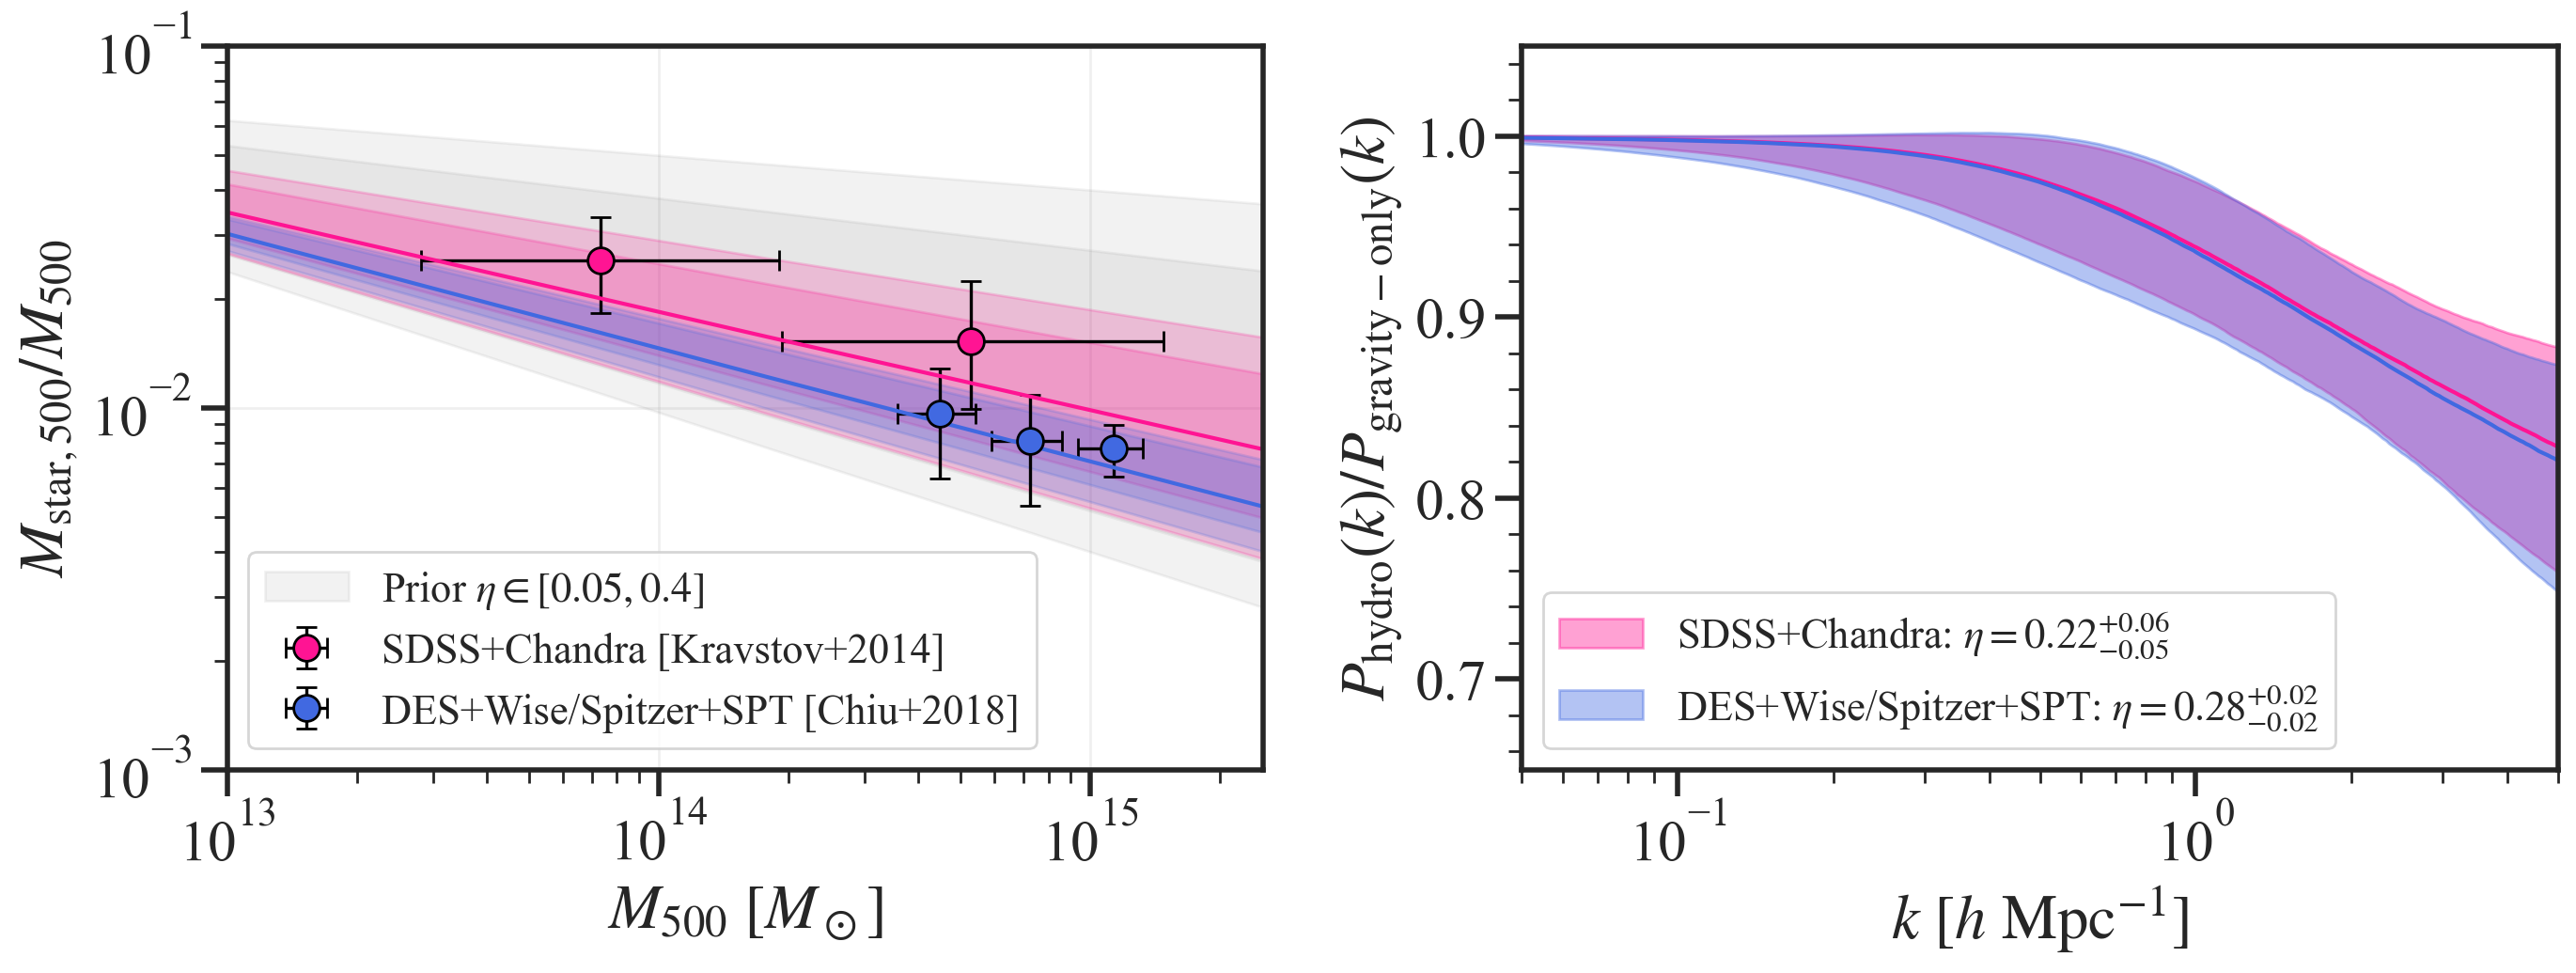

In [8]:
def sample_fstars(etas):
    """Return f_star_eta(M, eta) for a list/array of eta values."""
    return np.array([f_star_eta(M, eta=etas[i]) for i in tqdm(range(len(etas)))])

def plot_envelope(ax, fstars, color, alpha=0.2, label=None):
    """Plot median + 68% and 90% envelopes."""
    p = np.percentile
    ax.plot(M, p(fstars, 50, axis=0), color=color)
    ax.fill_between(M, p(fstars, 16, axis=0), p(fstars, 84, axis=0),
                    alpha=alpha, color=color)
    ax.fill_between(M, p(fstars, 5, axis=0),  p(fstars, 95, axis=0),
                    alpha=alpha, color=color)
    
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 5), sharey=False
)
plt.subplots_adjust(wspace=0.25)

# ------------------------------------------------------------
# ---------------------- LEFT PANEL --------------------------
#      Stellar mass fraction vs. M500 (f_* envelope)
# ------------------------------------------------------------

M = 10**np.linspace(13, 15.5, 3)

# --- Prior envelope ---------------------------------------------------------
prior_etas = np.random.uniform(0.05, 0.4, size=100)
prior_fstars = sample_fstars(prior_etas)

ax1.fill_between(
    M, np.percentile(prior_fstars, 16, axis=0), np.percentile(prior_fstars, 84, axis=0),
    alpha=0.1, color="gray", label="Prior $\\eta \\in [0.05, 0.4]$"
)
ax1.fill_between(
    M, np.percentile(prior_fstars, 5, axis=0), np.percentile(prior_fstars, 95, axis=0),
    alpha=0.1, color="gray"
)

# --- Data points -------------------------------------------------------------
ax1.errorbar(
    chandra_mass_med, chandra_mfrac_med,
    xerr=[chandra_mass_err_l, chandra_mass_err_h],
    yerr=[chandra_mfrac_err_l, chandra_mfrac_err_h],
    fmt='o', markersize=10, capsize=4,
    color='deeppink', markeredgecolor='black', ecolor='black',
    elinewidth=1.2, label="SDSS+Chandra [Kravstov+2014]"
)

ax1.errorbar(
    binned_spt_clusters["mean_M500"], binned_spt_clusters["mean_Mstar_M500"],
    xerr=binned_spt_clusters["err_M500"],
    yerr=binned_spt_clusters["err_Mstar_M500"],
    fmt='o', markersize=10, capsize=4,
    color='royalblue', markeredgecolor='black', ecolor='black',
    elinewidth=1.2, label="DES+Wise/Spitzer+SPT [Chiu+2018]"
)

# --- Posterior envelopes ----------------------------------------------------
plot_envelope(ax1, 
    sample_fstars(samples_chandra[:100]), 
    color="deeppink", label="Chandra posterior"
)
plot_envelope(ax1,
    sample_fstars(samples_spt[:100]), 
    color="royalblue", label="SPT posterior"
)

# --- Axes & formatting -------------------------------------------------------
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(10**13, 10**15.4)
ax1.set_ylim(1e-3, 0.1)
ax1.set_xlabel(r"$M_{500}~[M_\odot]$")
ax1.set_ylabel(r"$M_{\mathrm{star}, 500} / M_{500}$")
ax1.grid(alpha=0.3)
ax1.legend(loc="lower left", fontsize=16)


# ------------------------------------------------------------
# --------------------- RIGHT PANEL --------------------------
#     Ratio P_baryons(k) / P_gravity(k) (two priors)
# ------------------------------------------------------------

k_fields = np.geomspace(1e-4, 1e2, 1000)

variations = {
    "eta": ["Chandra", "SPT"],
}

labels = {
    "eta": [
        "SDSS+Chandra: $\eta = 0.22_{-0.05}^{+0.06}$",
        "DES+Wise/Spitzer+SPT: $\eta = 0.28_{-0.02}^{+0.02}$",
    ],
}

colors = ["deeppink", "royalblue"]

ax2.set(
    xscale="log",
    xlabel=r"$k~[h~\mathrm{Mpc}^{-1}]$",
    xlim=(5e-2, 5),
    ylim=(0.65, 1.05),
)

for i, var in enumerate(variations["eta"]):
    ratio_lo, ratio_med, ratio_hi = np.load(
        f"data/frb_results/spk_BCEmu5_extended_{var}prior.npy"
    )
    ax2.plot(k_fields/(cosmo.H0.value/100), ratio_med, color=colors[i])
    ax2.fill_between(
        k_fields/(cosmo.H0.value/100),
        ratio_lo,
        ratio_hi,
        color=colors[i],
        alpha=0.4,
        label=labels["eta"][i],
    )

ax2.set_ylabel(r"$P_\mathrm{hydro}(k)/P_\mathrm{gravity-only}(k)$")

ax2.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax2.yaxis.set_minor_locator(plt.MultipleLocator(0.02))

ax2.legend(loc="lower left", fontsize=16)  

plt.savefig('figures/eta_prior_bfg.pdf', dpi=400, bbox_inches='tight')

